Saving delivery.csv to delivery (10).csv


,n.prod,distance,delTime
0,7,560,16.68
1,3,220,11.50
2,3,340,12.03
3,4,80,14.88
4,6,150,13.75


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   n.prod    25 non-null     int64  
 1   distance  25 non-null     int64  
 2   delTime   25 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 732.0 bytes
Intercept: 2.3412311451922108 
Coefficients: [1.61590721 0.01438483]


'VIF:'

,0
n.prod,7.848245
distance,7.848245


model1 score: 0.9304813135986856
model1 score: 0.9595937494832257


'adjusted rscore:'

0.9559204539817008

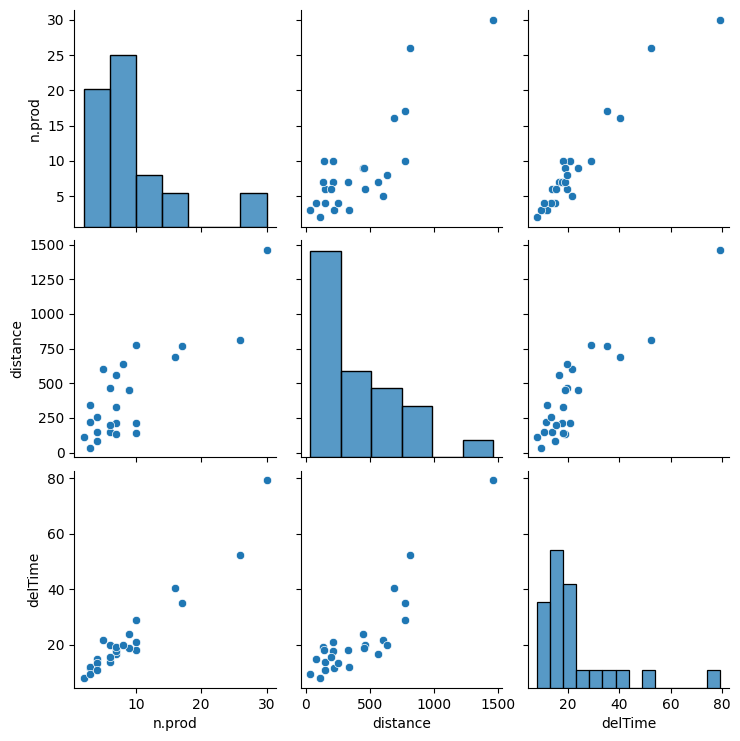

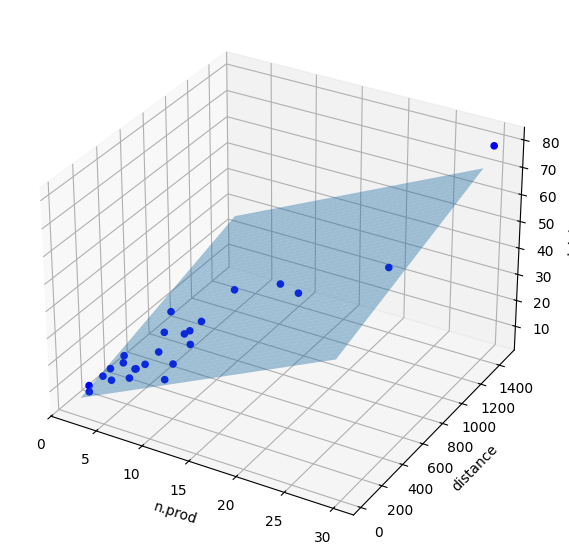

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
%matplotlib inline

uploaded = files.upload()
delivery_filename = next(iter(uploaded))

df = pd.read_csv(io.StringIO(uploaded[delivery_filename].decode('utf-8')))
display(df.head())
df.info()

# Visualizing data
import seaborn as sns
sns.pairplot(df)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
# selecting the predictors and targets
X = df[["n.prod","distance"]]
y = df["delTime"]
model.fit(X,y)
print("Intercept:",model.intercept_ ,"\nCoefficients:",model.coef_)

#Setting up the plot area
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(xs = df["n.prod"], ys = df["distance"], zs=df["delTime"],c='blue',alpha=1,marker='o')
ax.set_xlabel("n.prod")
ax.set_ylabel("distance")
ax.set_zlabel("delTime")
x_surf = np.arange(df["n.prod"].min(), df["n.prod"].max(), 1)
y_surf = np.arange(df["distance"].min(), df["distance"].max(), 1)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)
X_mesh = pd.core.frame.DataFrame({'n.prod': x_surf.ravel(), 'distance': y_surf.ravel()})
out = model.predict(X_mesh)
ax.plot_surface(x_surf, y_surf,out.reshape(x_surf.shape),alpha = 0.4)

# finding the correlation
np.corrcoef(df["n.prod"],df["distance"])
from statsmodels.stats.outliers_influence import variance_inflation_factor
#calculating the VIF for each attributes
vif = pd.Series([variance_inflation_factor(X.values,idx)
           for idx in range(X.shape[1])],
          index=X.columns)
display('VIF:',vif)

model.score(X,y)
# Model with a single predictor - n.prod
model1 = LinearRegression()
features = ["n.prod"]
target = ["delTime"]
model1.fit(df[features],df[target])
print('model1 score:',model1.score(df[features],df[target]))
model2 = LinearRegression()
features = ["n.prod","distance"]
target = ["delTime"]
model2.fit(df[features],df[target])
print('model1 score:',model2.score(df[features],df[target]))
#computation of adjusted R-squared
X = df[features]
y = df[target]
adjusted_rscore = 1 - (1-model2.score(X, y))*(len(y)-1)/(len(y)-X.shape[1]-1)
display('adjusted rscore:',adjusted_rscore)



